# Failure Analysis

Analysis and visualization of failure cases for experiment data.

Please use `warn` or `error` to log any unexpected warnings or errors when plotting/processing the data.
Please insert any code blocks before the last `check_results()` codeblock.

In [1]:
from colorama import Fore, Back, Style
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import matplotlib.axes as axes
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.container as container
import matplotlib.patches as patches
from typing import List, cast
from IPython.display import display
import os
import re
import math
from pathlib import Path
plt.rcParams['figure.dpi'] = 150

PALETTE_COLORS = sns.color_palette('pastel')
sns.set_theme(style="whitegrid", palette="pastel", font_scale=0.8)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

def to_snake_case(text: str) -> str:
    """Convert text to snake_case, and removes any punctuation symbols
    that make it unsuitable to be used in a file name.

    Args:
        text (str): String to convert.

    Returns:
        str: String in snake_case.
    """
    # Replace all non-alphanumeric characters (excluding underscores) with a single space.
    text = re.sub(r'[^\w\s-]', ' ', text)

    # Convert PascalCase to snake_case
    text = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', text)
    text = text.lower()

    # Convert Space Case to snake_case
    text = re.sub(r'[\s-]+', '_', text)

    # Remove repeating or trailing underscores
    text = re.sub(r'_{2,}', '_', text)
    text = text.strip('_')
    return text

ERRORS: List[str] = []
WARNINGS: List[str] = []

def error(msg: str):
    """Prints an error.

    Args:
        msg (str): Error message.
    """
    global ERRORS
    ERRORS.append(msg)
    print(Fore.RED + Style.BRIGHT + f"🛑 Error: {msg}")

def warn(msg: str):
    """Prints a warning.

    Args:
        msg (str): Warning message.
    """
    global WARNINGS
    WARNINGS.append(msg)
    print(Fore.YELLOW + Style.BRIGHT + f"⚠️ Warn: {msg}")

def check_results():
    """Prints any errors or warnings that were encountered.
    """
    print("Data Analysis Results:")
    if len(ERRORS) > 0:
        print(Fore.RED + Style.BRIGHT + f"🛑 Errors: {len(ERRORS)}")
        for msg in ERRORS:
            print(Fore.RED + Style.BRIGHT + f"  - {msg}")
    if len(WARNINGS) > 0:
        print(Fore.YELLOW + Style.BRIGHT + f"⚠️ Warn: {len(WARNINGS)}")
        for msg in WARNINGS:
            print(Fore.YELLOW + Style.BRIGHT + f"  - {msg}")

In [ ]:
# SCENE_SUMMARY_CSV_PATH = "../tests/scenes/final/scene_summary.csv"
SCENE_SUMMARY_CSV_PATH = "./data/scene_summary.csv"
EXPERIMENT_SUMMARY_CSV_PATH = "./data/IROS/sim_final_experiment_summary.csv"
PLOT_PREFIX = ""
PLOTS_PATH = "./plots"
RUNS_PATH = "./runs"
ROOT_PATH = ".."
os.makedirs(PLOTS_PATH, exist_ok=True)

# Scene summary DataFrame
#
# Each row represents a single scene, and stores information about 
# that scene, such as the objects that are initially on the table, on the floor, etc. 
sc_df = pd.read_csv(SCENE_SUMMARY_CSV_PATH)
display(sc_df.info(verbose=True))
display(sc_df)

# Experiment summary DataFrame
# 
# Each row represents a single experiment, and stores information about 
# that experiment, such as the result of the experiments, any errors, etc.
ex_df = pd.read_csv(EXPERIMENT_SUMMARY_CSV_PATH)

# bg_fix_df = pd.read_csv("./data/all_bug_fixed_experiment_summary.csv")
# # Rename ex_df methods with dg_only to dg_only_new
# ex_df['Method'] = ex_df['Method'].apply(lambda x: x.replace('dg_only', 'dg_only_new'))

# # Stack bg_fix_df into ex_df
# ex_df = pd.concat([ex_df, bg_fix_df], ignore_index=True)

display(ex_df.info(verbose=True))
display(ex_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Scene          45 non-null     object
 1   Path           45 non-null     object
 2   All Objects    45 non-null     object
 3   Floor Objects  22 non-null     object
 4   Table Objects  45 non-null     object
dtypes: object(5)
memory usage: 1.9+ KB


None

,Scene,Path,All Objects,Floor Objects,Table Objects
0,unstructured_10,tests/scenes/final/unstructured_10.xml,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000...",NaN,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000..."
1,unstructured_134,tests/scenes/final/unstructured_134.xml,"obj_000054_0,obj_000062_0,obj_000066_0,obj_000...",obj_000062_0,"obj_000054_0,obj_000066_0,obj_000047_0,obj_000..."
2,difficult_130,tests/scenes/final/difficult_130.xml,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000...",NaN,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000..."
3,unstructured_36,tests/scenes/final/unstructured_36.xml,"obj_000003_0,obj_000012_0,obj_000013_0,obj_000...",obj_000013_0,"obj_000003_0,obj_000012_0,obj_000054_0,obj_000..."
4,difficult_149,tests/scenes/final/difficult_149.xml,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000...",NaN,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000..."
...,...,...,...,...,...
40,structured_590,tests/scenes/final/structured_590.xml,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000...",obj_000029_0,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000..."
41,unstructured_105,tests/scenes/final/unstructured_105.xml,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000...",NaN,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000..."
42,difficult_179,tests/scenes/final/difficult_179.xml,"obj_000015_0,obj_000053_0,obj_000055_0,obj_000...","obj_000032_0,obj_000073_0","obj_000015_0,obj_000053_0,obj_000055_0,obj_000..."
43,structured_586,tests/scenes/final/structured_586.xml,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000...",NaN,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720 entries, 0 to 1719
Data columns (total 38 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Init Import Duration                           1720 non-null   float64
 1   Init Perception Planning Duration              1720 non-null   float64
 2   Init Functions Duration                        1720 non-null   float64
 3   Init Post Duration                             1720 non-null   float64
 4   Total Init Duration                            1720 non-null   float64
 5   Target Object                                  1720 non-null   object 
 6   Pick Count                                     1720 non-null   float64
 7   Grasp Choice (Seg ID)                          1720 non-null   object 
 8   Grasp Choice Duration                          1720 non-null   object 
 9   Error                                          1429 

None

,Init Import Duration,Init Perception Planning Duration,Init Functions Duration,Init Post Duration,Total Init Duration,Target Object,Pick Count,Grasp Choice (Seg ID),Grasp Choice Duration,Error,Grasp Score,Total Computation Duration,Total Grasp Planning Duration,Total Motion Planning Duration,Object Name,Grasp Success,Grasped,Total Execution Duration,Retract Success,Dropped,Grasp Result,Retrieved Target Object,Grasp Retracted Objects,Accidental Dropped Objects,Grasp Result finished Count,Grasp Result timeout Count,Grasp Result no_valid_grasps_found Count,Grasp Result grasp_choice_failed Count,Grasp Result no_valid_motion_plan_found Count,Grasp Success True Count,Grasp Success False Count,Grasp Retracted Objects Count,Accidental Dropped Objects Count,Scene,Experiment Path,Method,Total Experiment Time,Dropped Target Object
0,0.952005,1.048262,0.000337,0.051611,2.052825,obj_000056_1,3.0,"5.0,9.0,0.0","14.877943515777588,48.54696559906006,103.42640...",MotionGenStatus.INVALID_START_STATE_WORLD_COLL...,"1.0,1.0,1.0","97.97129154205322,106.29112148284912,151.46847...","38.61361575126648,35.74237608909607,30.9801814...","35.392438650131226,13.9506938457489,9.99864029...","obj_000052_0,obj_000122_0,obj_000056_1","True,True,True","['obj_000052_0'],['obj_000122_0', 'obj_000056_...","36.54970598220825,33.55684471130371,32.1611456...","True,True,True","obj_000029_0,obj_000122_0,obj_000052_0","finished,finished,finished",True,"obj_000005_0,obj_000056_1,obj_000122_0,obj_000...",obj_000029_0,3,0,0,0,0,3,0,7,1,structured_590,trial_2026-03-02_02-20-07__all__human/structur...,human,511.251949,NaN
1,1.013295,1.092211,0.000229,0.040674,2.147032,obj_000082_1,4.0,"8,13,0,0","15.892080307006836,16.075857877731323,6.253121...",MotionGenStatus.INVALID_START_STATE_WORLD_COLL...,"1.0,1.0,1.0,1.0","57.50319933891296,51.15751838684082,39.1767127...","27.53994965553284,20.654581785202023,16.331273...","8.320314884185791,9.121776819229126,11.7787764...","obj_000090_0,obj_000098_1,obj_000082_1,obj_000...","True,True,False,True","['obj_000090_0', 'obj_000091_3'],['obj_000098_...","20.27651810646057,24.773998498916622,23.997572...","False,True,False,True","obj_000098_1,obj_000086_0","finished,finished,finished,finished",True,"obj_000098_1,obj_000082_1",obj_000086_0,4,0,0,0,0,3,1,2,1,structured_483,trial_2026-03-02_02-20-07__all__human/structur...,human,371.686320,NaN
2,0.914187,1.065685,0.000183,0.029917,2.010645,obj_000046_0,4.0,"7,7,8,0","17.81791925430298,17.205392599105835,21.648487...",MotionGenStatus.INVALID_START_STATE_WORLD_COLL...,"1.0,1.0,1.0,0.6666666666666666","82.84518957138062,56.365819692611694,57.142932...","29.47363567352295,27.56662392616272,25.8211157...","30.343873977661133,6.6847851276397705,5.426376...","obj_000059_0,obj_000059_0,obj_000050_0,obj_000...","False,True,True,True","[],['obj_000059_0'],['obj_000050_0'],['obj_000...","51.27761220932007,29.363535165786743,28.944150...","False,True,True,True","obj_000050_0,obj_000059_0","finished,finished,finished,finished",True,"obj_000050_0,obj_000059_0,obj_000046_0",NaN,4,0,0,0,0,3,1,3,0,structured_251,trial_2026-03-02_02-20-07__all__human/structur...,human,428.220402,NaN
3,0.945606,1.133865,0.000207,0.049220,2.129587,obj_000005_0,2.0,"10,0","37.92335367202759,16.558432817459106",NaN,"1.0,1.0","73.01875019073486,43.228999376297","21.989548206329346,16.839449167251587","7.479664802551269,5.047592401504517","obj_000074_0,obj_000005_0","True,True","['obj_000074_0'],['obj_000005_0']","32.08128643035889,31.56645464897156","True,True",obj_000074_0,"finished,finished",True,"obj_000005_0,obj_000074_0",NaN,2,0,0,0,0,2,0,2,0,structured_198,trial_2026-03-02_02-20-07__all__human/structur...,human,211.454088,NaN
4,12.485617,45.402905,0.000037,0.097713,57.986970,obj_000059_0,6.0,"2.0,3.0,9.0,10.0,-1.0,10.0,-1.0,1.0,0.0","32.99579429626465,7.798290491104126,28.0935144...",MotionGenStatus.INVALID_START_STATE_WORLD_COLL...,"1.0,1.0,1.0,1.0,1.0","165.4887511730194,54.44874453544617,150.466332...","23.8439993858

In [46]:
def post_process_ex_df(ex_df: pd.DataFrame) -> pd.DataFrame:
    """Processes a raw experiment DataFrame, adding more columns and removing invalid data.

    Args:
        ex_df (pd.DataFrame): Experiment DataFrame to process.
    """
    # Force "Scene" to be a string column
    ex_df["Scene"] = ex_df["Scene"].astype(str)
    def process_scene_type(row):
        parts = row["Scene"].split('_')
        if len(parts) >= 2:
            return parts[-2]
        else:
            return "unknown"
    ex_df["Scene Type"] = ex_df.apply(process_scene_type, axis=1)
    ex_df["Scene"] = ex_df["Scene"].str.replace("tabletop_", "")
    ex_df["Error Count"] = ex_df["Error"].str.split(',').str.len().fillna(0).astype(int)
    ex_df["Grasp Result Count"] = ex_df["Grasp Result"].str.split(",").str.len().fillna(0).astype(int)
    ex_df["Grasp Result Failure"] = (
        ex_df["Grasp Result"]
        .str.split(",")
        .apply(lambda x: [item for item in x if item != "finished"])
        .str.join(",")
        .replace("", pd.NA) 
    )
    ex_df["Grasp Result Failure Count"] = ex_df["Grasp Result Failure"].str.split(",").str.len().fillna(0).astype(int)
    ex_df["Experiment"] = ex_df["Scene"] + " " + ex_df["Target Object"]

    # Create "Experiment Result" column based on outcomes
    conditions = []
    choices = []
    if "Dropped Target Object" in ex_df:
        conditions.append(ex_df["Dropped Target Object"] == True)
        choices.append("dropped")
    if "Retrieved Target Object" in ex_df:
        conditions.append(ex_df["Retrieved Target Object"] == True)
        choices.append("retrieved")
    if "Unhandled Error" in ex_df:
        conditions.append(ex_df["Unhandled Error"].notna())
        choices.append("error")
    if "Retrieved Target Object" in ex_df:
        conditions.append(ex_df["Retrieved Target Object"] == False)
        choices.append("timeout")

    ex_df['Experiment Result'] = np.select(conditions, choices, default='unfinished')
    ex_df["Retrieve Success"] = ex_df['Experiment Result'] == "retrieved"

    # Create "Experiment Detailed Result" column
    # For timeout experiments, append the most prevalent grasp result
    # For others, just use the Experiment Result
    def get_most_prevalent_grasp_result(grasp_result_str):
        if pd.isna(grasp_result_str) or grasp_result_str == "":
            return None
        grasp_results = [item.strip() for item in grasp_result_str.split(",")]
        if not grasp_results:
            return None
        # Filter out finished
        grasp_results = [result for result in grasp_results if result != "finished"]
        if not grasp_results:
            # Only consider finished if it's the only result
            return "finished"
        # Count occurrences and get the most common
        from collections import Counter
        counts = Counter(grasp_results)
        return counts.most_common(1)[0][0]
    
    def create_detailed_result(row):
        exp_result = row['Experiment Result']
        if exp_result == "timeout":
            most_prevalent = get_most_prevalent_grasp_result(row['Grasp Result'])
            if most_prevalent:
                return f"timeout + {most_prevalent}"
            else:
                return "timeout"
        else:
            return exp_result
    
    ex_df['Experiment Detailed Result'] = ex_df.apply(create_detailed_result, axis=1)

    # Fix accidental dropped objects
    # Exclude target object from being considered as accidental dropped if it made the experiment fail.
    def exclude_floor_objects_and_target(ex_df: pd.DataFrame, sc_df: pd.DataFrame):
        ex_df["Accidental Dropped Objects List"] = ex_df["Accidental Dropped Objects"].fillna('').str.split(',')
        ex_df["Accidental Dropped Objects List"] = ex_df["Accidental Dropped Objects List"].apply(
            lambda x: [] if (len(x) == 1 and x[0].strip() == '') else x
        )
        display(sc_df)
        def apply_floor(row: pd.Series):
            first = row.iloc[0]
            if not isinstance(first, str):
                return set()
            return set(first.split(","))
        scene_invalid_objects = sc_df.groupby('Scene')['Floor Objects'].apply(apply_floor).to_dict()
        def filter_objects_by_scene(row):
            scene = row['Scene']
            dropped_objects = row['Accidental Dropped Objects List'] 
            invalid_set = scene_invalid_objects.get(scene, set())
            invalid_set.add(row['Target Object'])
            cleaned_list = [
                obj.strip()
                for obj in dropped_objects
                if obj.strip() and obj.strip() not in invalid_set
            ]
            return cleaned_list
        
        ex_df["Accidental Dropped Objects List"] = ex_df.apply(
            filter_objects_by_scene,
            axis=1
        )
        ex_df["Accidental Dropped Objects"] = ex_df["Accidental Dropped Objects List"].apply(
            lambda x: ", ".join(x)
        )
        ex_df["Accidental Dropped Objects Count"] = ex_df["Accidental Dropped Objects List"].apply(len)
    
    exclude_floor_objects_and_target(ex_df, sc_df)

    if "Experiment Path" not in ex_df.columns:
        ex_df["Experiment Path"] = ex_df["Scene"]

post_process_ex_df(ex_df)

display(ex_df.info(verbose=True))
display(ex_df.loc[~ex_df["Retrieve Success"] & ex_df["Accidental Dropped Objects"], ["Experiment Path", "Accidental Dropped Objects", "Target Object", "Retrieve Success"]])

,Scene,Path,All Objects,Floor Objects,Table Objects
0,unstructured_10,tests/scenes/final/unstructured_10.xml,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000...",NaN,"obj_000051_0,obj_000047_0,obj_000053_0,obj_000..."
1,unstructured_134,tests/scenes/final/unstructured_134.xml,"obj_000054_0,obj_000062_0,obj_000066_0,obj_000...",obj_000062_0,"obj_000054_0,obj_000066_0,obj_000047_0,obj_000..."
2,difficult_130,tests/scenes/final/difficult_130.xml,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000...",NaN,"obj_000051_0,obj_000051_1,obj_000048_0,obj_000..."
3,unstructured_36,tests/scenes/final/unstructured_36.xml,"obj_000003_0,obj_000012_0,obj_000013_0,obj_000...",obj_000013_0,"obj_000003_0,obj_000012_0,obj_000054_0,obj_000..."
4,difficult_149,tests/scenes/final/difficult_149.xml,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000...",NaN,"obj_000054_0,obj_000054_1,obj_000062_0,obj_000..."
...,...,...,...,...,...
40,structured_590,tests/scenes/final/structured_590.xml,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000...",obj_000029_0,"obj_000004_0,obj_000005_0,obj_000041_0,obj_000..."
41,unstructured_105,tests/scenes/final/unstructured_105.xml,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000...",NaN,"obj_000069_0,obj_000069_1,obj_000070_0,obj_000..."
42,difficult_179,tests/scenes/final/difficult_179.xml,"obj_000015_0,obj_000053_0,obj_000055_0,obj_000...","obj_000032_0,obj_000073_0","obj_000015_0,obj_000053_0,obj_000055_0,obj_000..."
43,structured_586,tests/scenes/final/structured_586.xml,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000...",NaN,"obj_000004_0,obj_000005_0,obj_000006_0,obj_000..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720 entries, 0 to 1719
Data columns (total 48 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Init Import Duration                           1720 non-null   float64
 1   Init Perception Planning Duration              1720 non-null   float64
 2   Init Functions Duration                        1720 non-null   float64
 3   Init Post Duration                             1720 non-null   float64
 4   Total Init Duration                            1720 non-null   float64
 5   Target Object                                  1720 non-null   object 
 6   Pick Count                                     1720 non-null   float64
 7   Grasp Choice (Seg ID)                          1720 non-null   object 
 8   Grasp Choice Duration                          1720 non-null   object 
 9   Error                                          1429 

None

,Experiment Path,Accidental Dropped Objects,Target Object,Retrieve Success
41,trial_2026-03-01_15-09-34__all__human/structur...,obj_000090_0,obj_000082_1,False
94,trial_2026-02-28_02-16-28__all__all_auto/unstr...,obj_000068_0,obj_000043_0,False
100,trial_2026-02-28_02-16-28__all__all_auto/unstr...,obj_000054_0,obj_000079_1,False
166,trial_2026-02-28_02-16-28__all__all_auto/unstr...,obj_000047_0,obj_000079_1,False
169,trial_2026-02-28_02-16-28__all__all_auto/struc...,"obj_000050_1, obj_000027_0",obj_000048_0,False
...,...,...,...,...
1642,trial_2026-02-28_02-16-30__all__all_auto/unstr...,obj_000068_0,obj_000065_0,False
1653,trial_2026-02-28_02-16-30__all__all_auto/unstr...,obj_000062_0,obj_000047_1,False
1659,trial_2026-02-28_02-16-30__all__all_auto/struc...,obj_000028_0,obj_000017_0,False
1661,trial_2026-02-28_02-16-30__all__all_auto/unstr...,"obj_000059_0, obj_000067_0",obj_000044_0,False


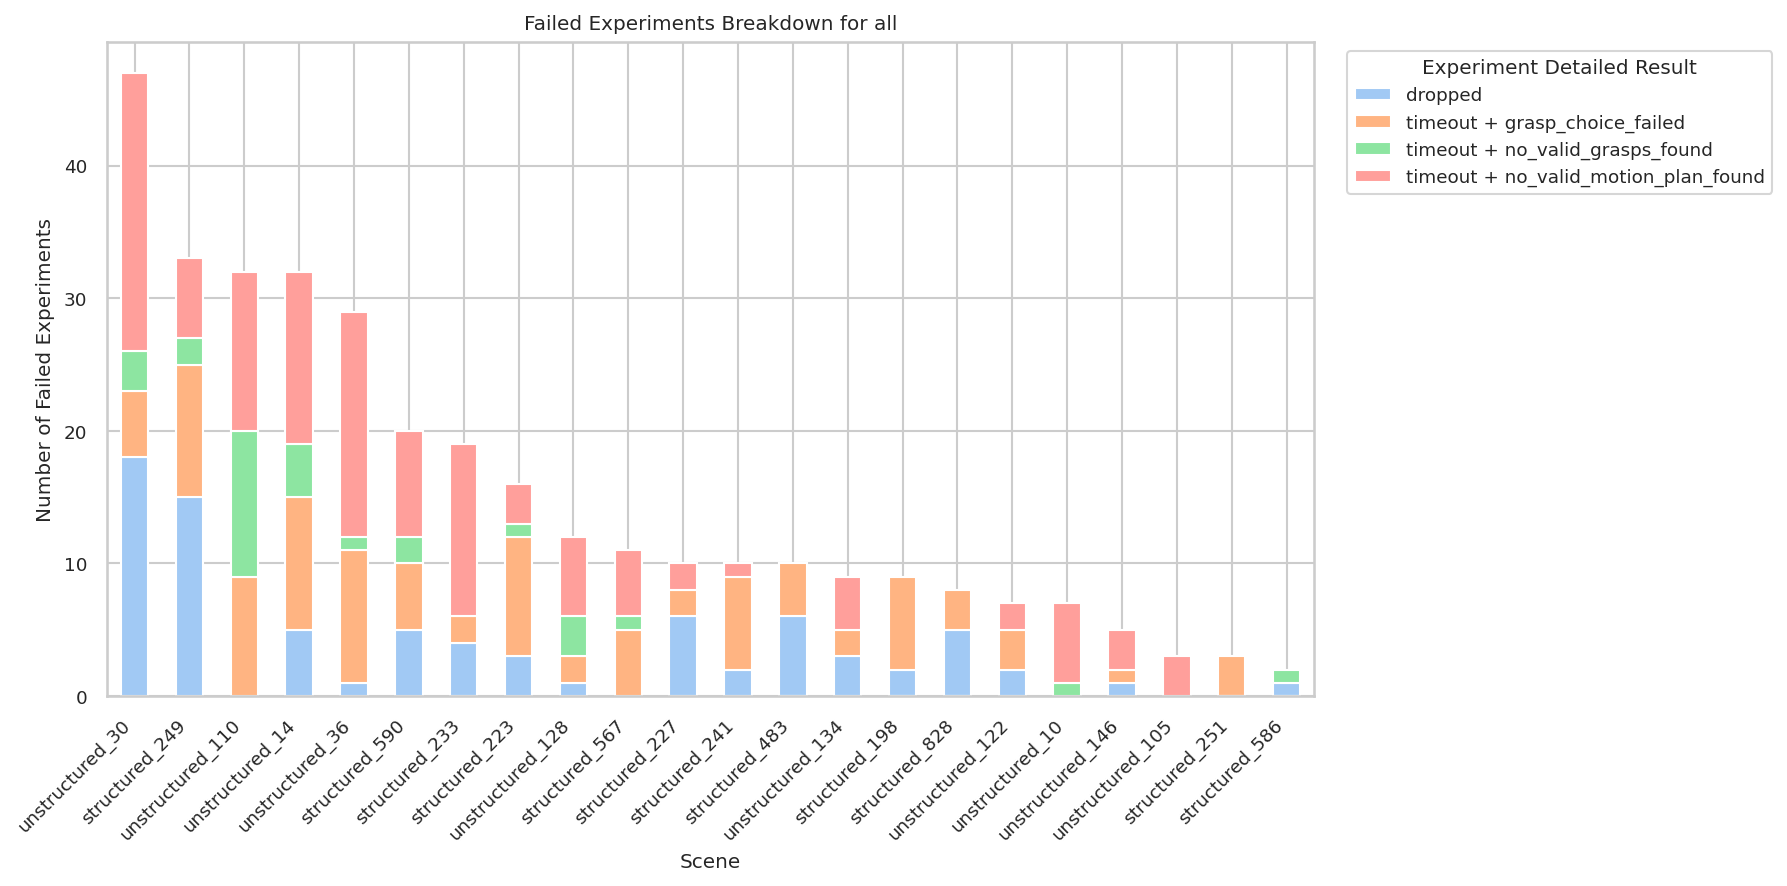

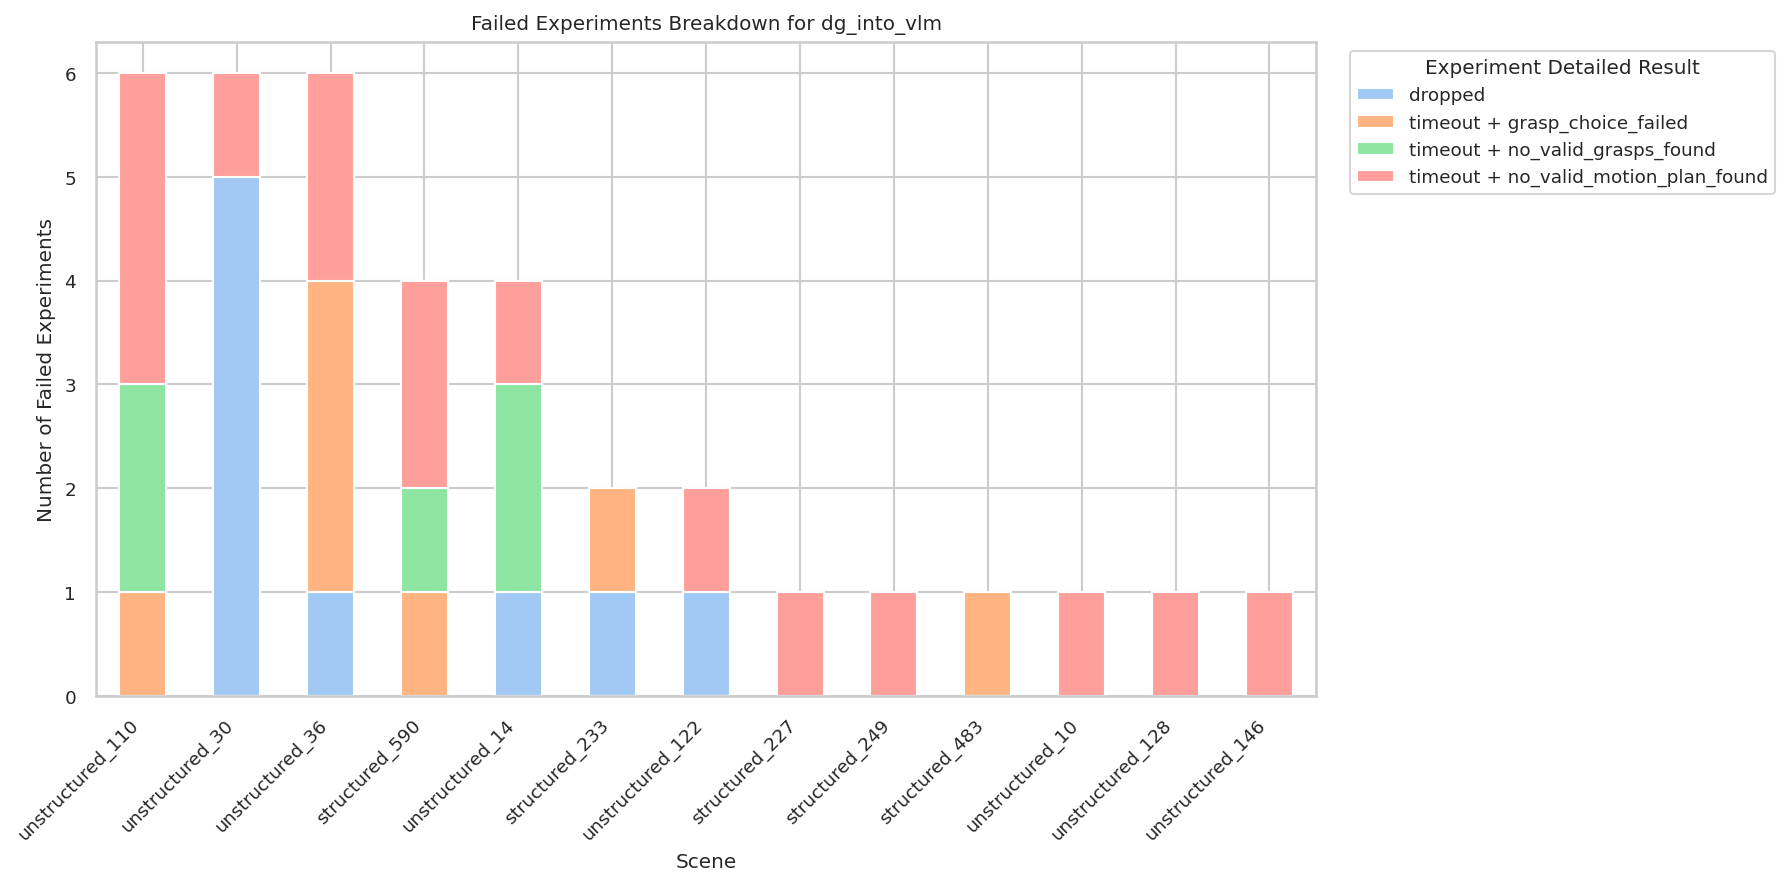

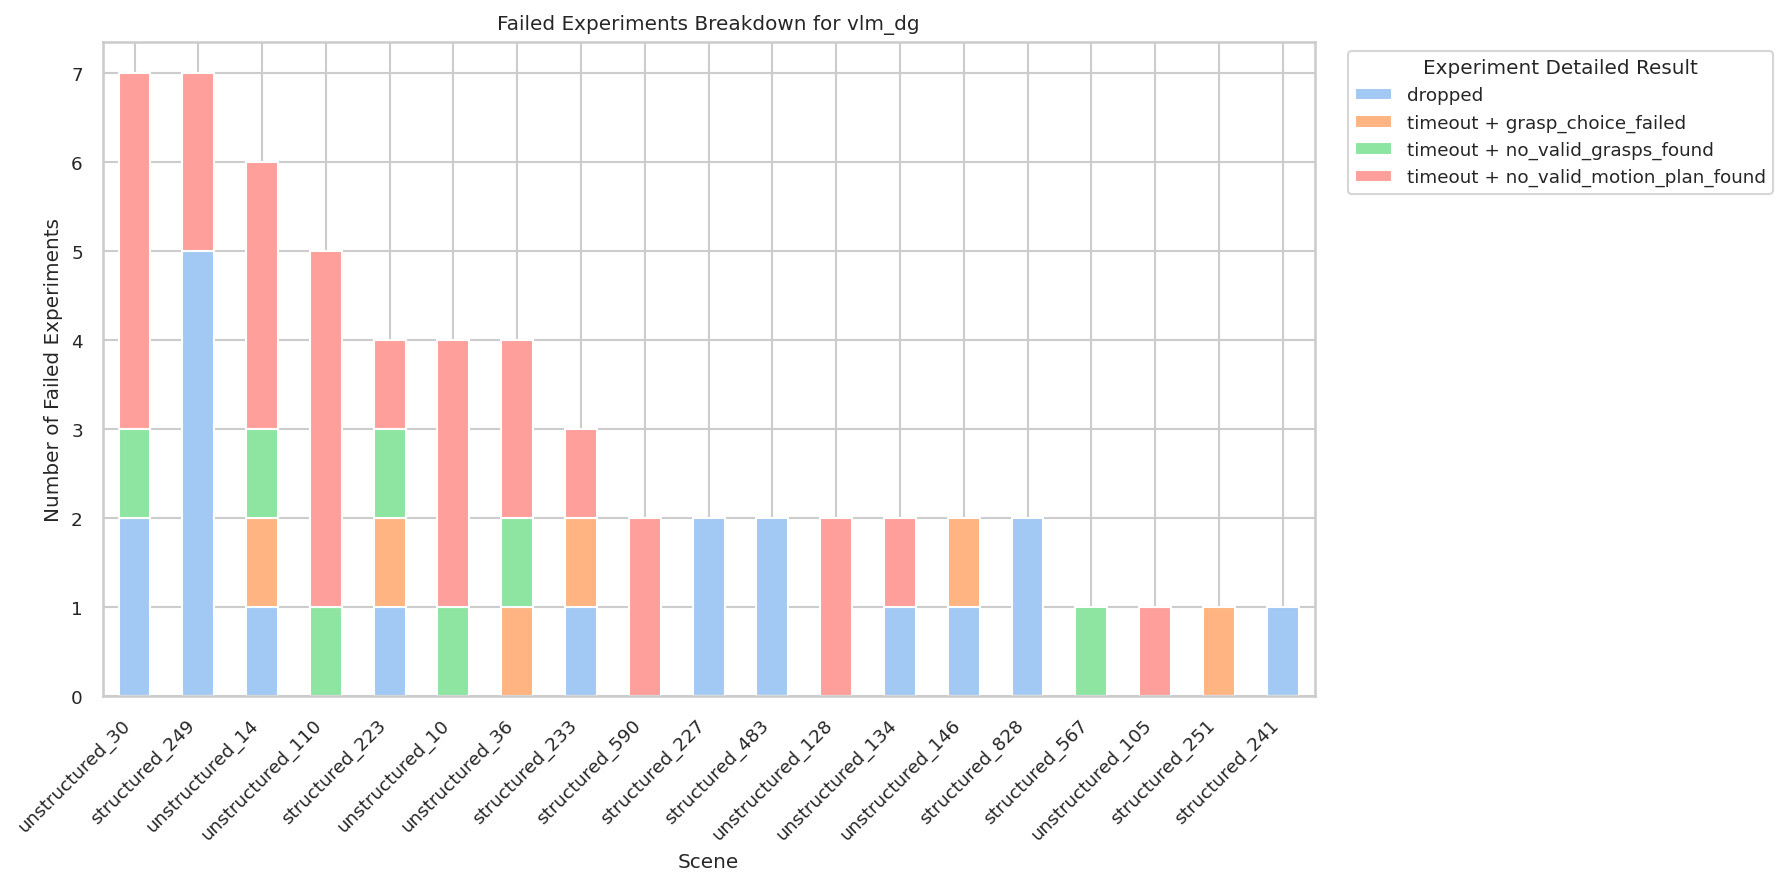

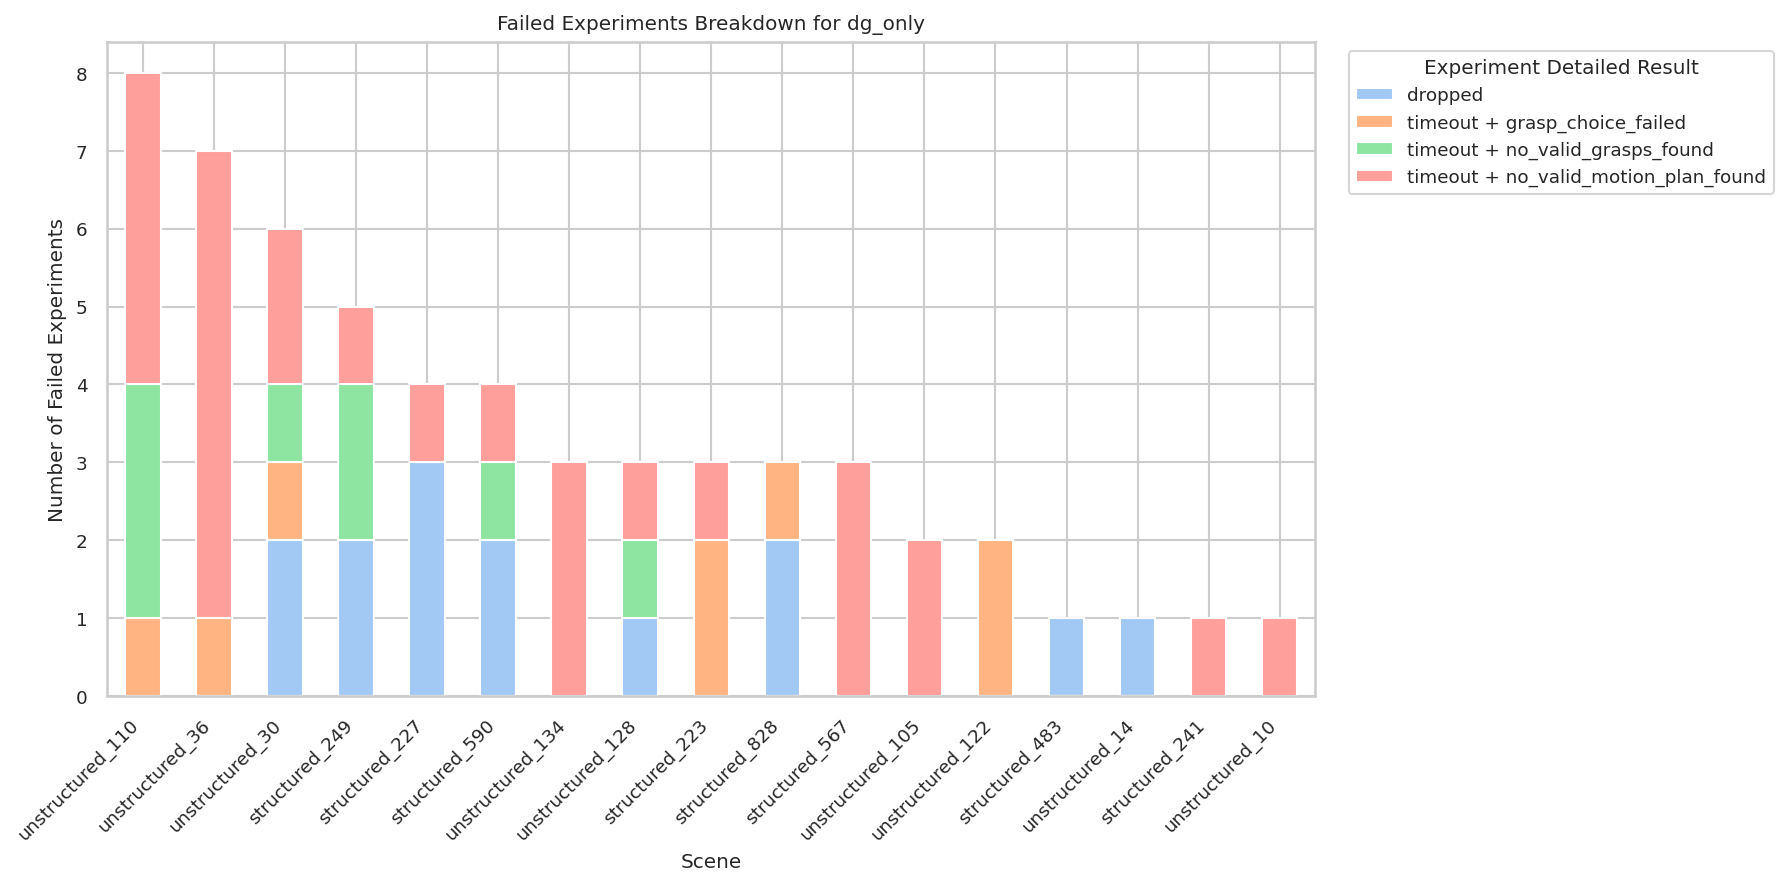

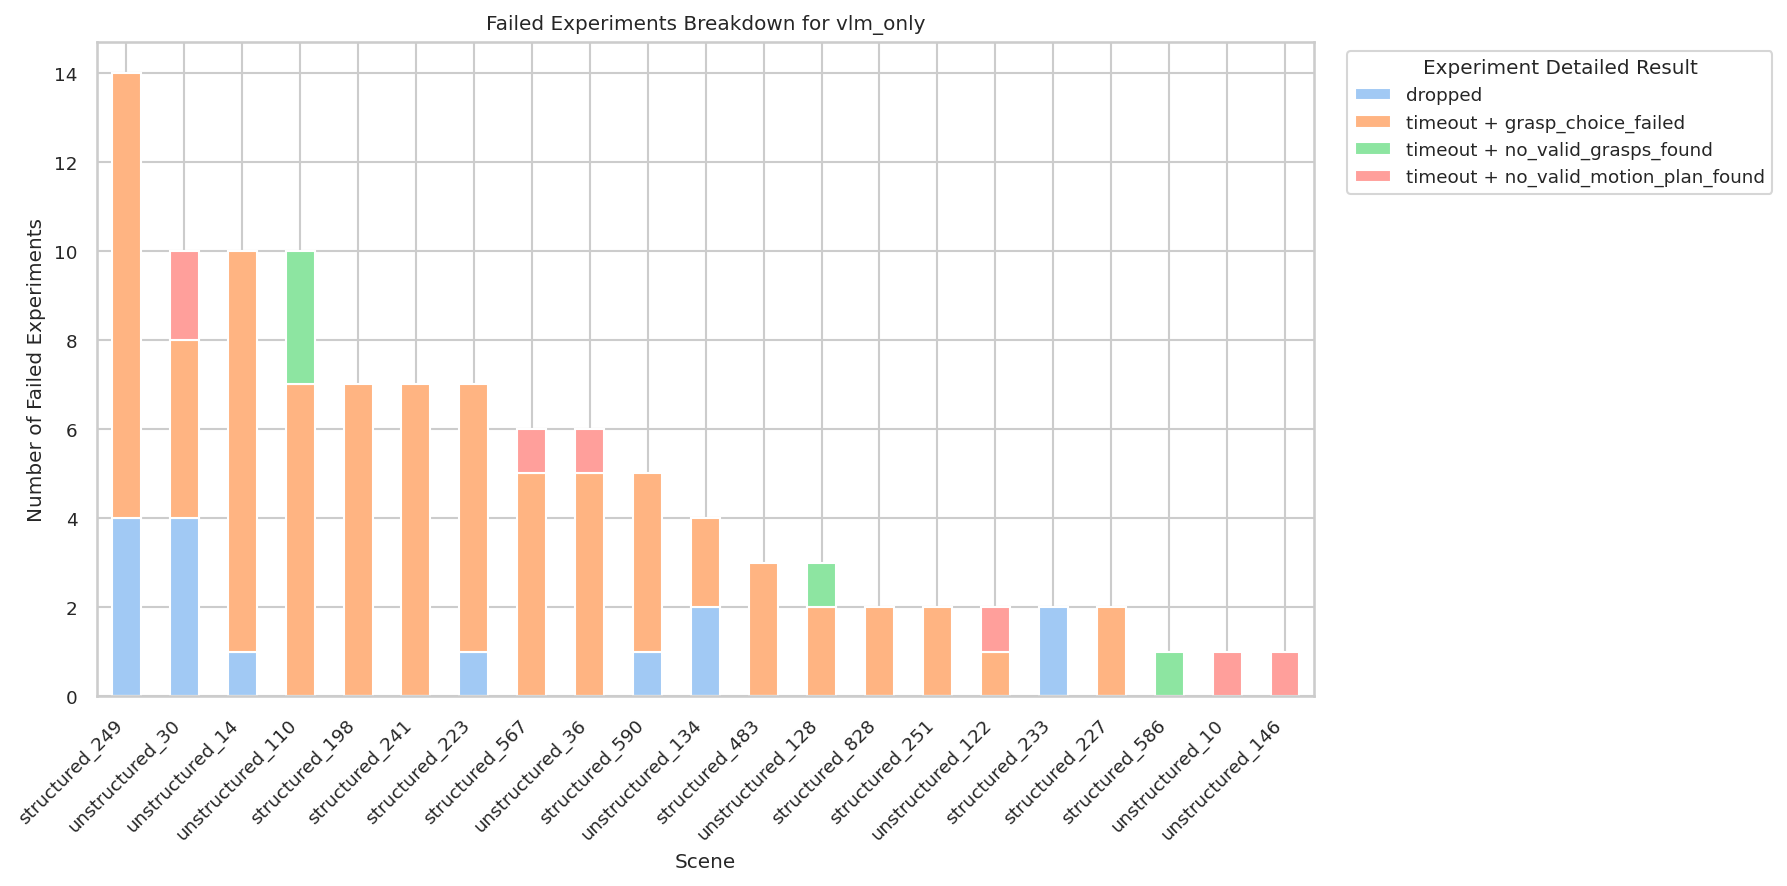

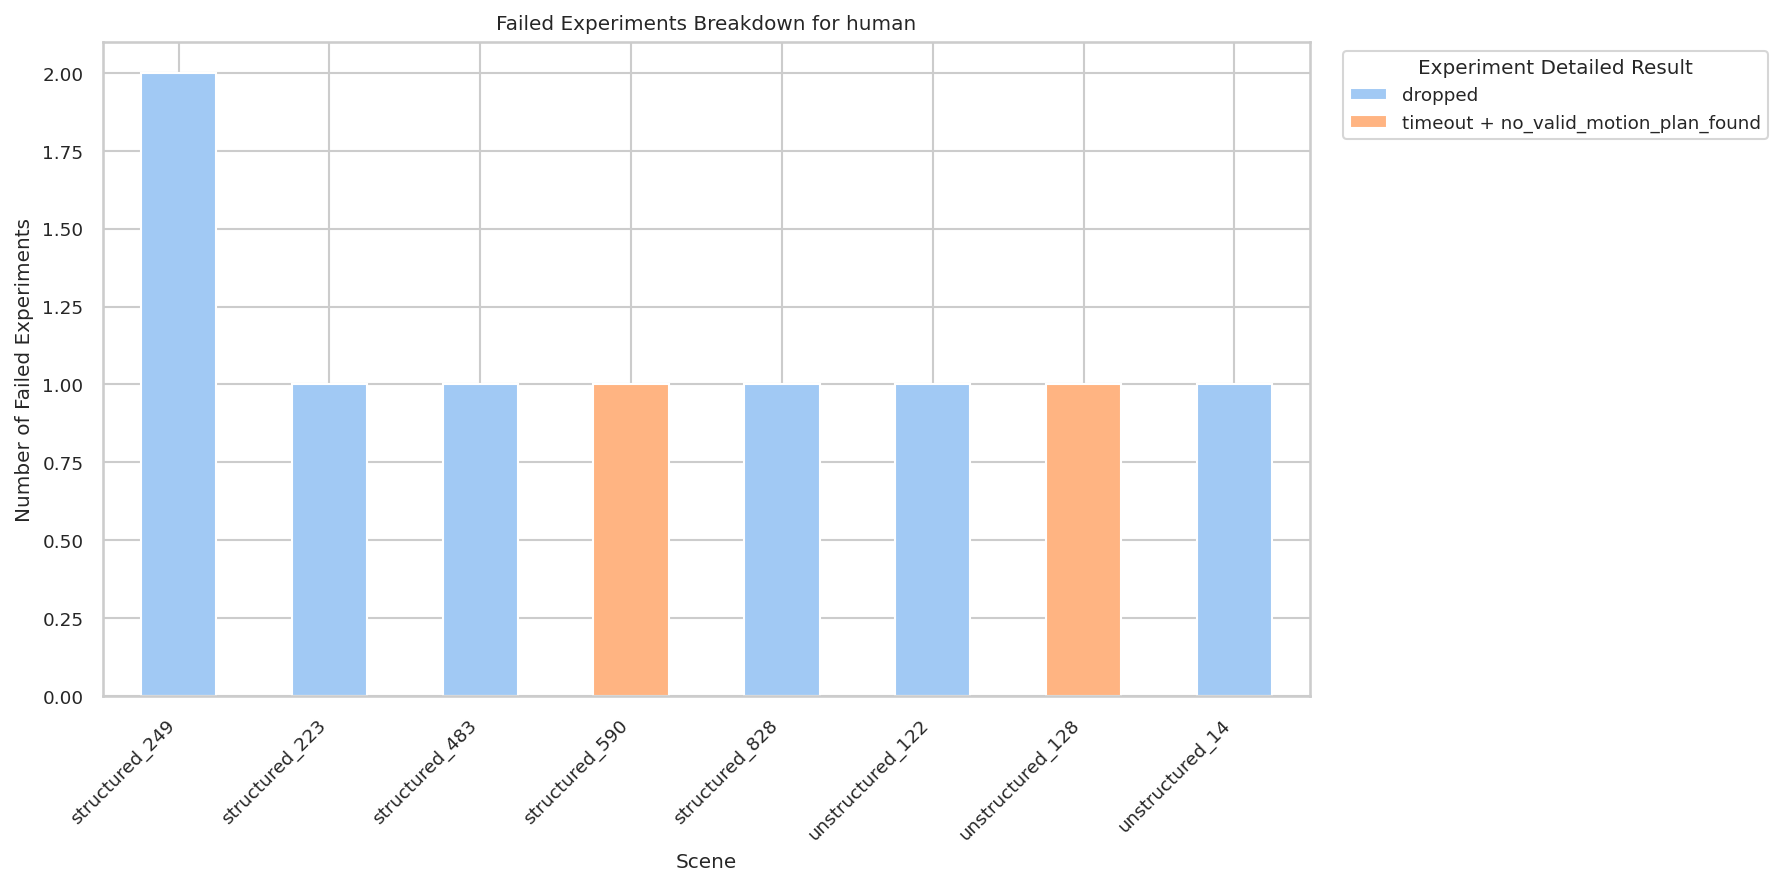

In [48]:
def plot_retrieve_failure_breakdown(df: pd.DataFrame, method: str = "dg_into_vlm", group_by_target: bool = False):
    if method != "all":
        df = df.loc[
            df["Method"] == method,
        ]

    if group_by_target:
        failure_df = df.loc[df["Experiment Detailed Result"] != "retrieved", ["Scene", "Target Object", "Experiment Detailed Result"]]
        groupby_cols = ["Scene", "Target Object", "Experiment Detailed Result"]
        xlabel = "Scene, Target Object"
    else:
        failure_df = df.loc[df["Experiment Detailed Result"] != "retrieved", ["Scene", "Experiment Detailed Result"]]
        groupby_cols = ["Scene", "Experiment Detailed Result"]
        xlabel = "Scene"
    
    if failure_df.empty:
        warn("No failed experiments found (all Experiment Detailed Result values are 'retrieved').")
        return

    failure_counts = (
        failure_df.groupby(groupby_cols)
        .size()
        .unstack(fill_value=0)
    )
    failure_counts = failure_counts.loc[failure_counts.sum(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    failure_counts.plot(kind="bar", stacked=True, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of Failed Experiments")
    ax.set_title(f"Failed Experiments Breakdown for {method}")
    plt.xticks(rotation=45, ha="right")
    ax.legend(title="Experiment Detailed Result", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    plt.tight_layout()
    output_path = f"{PLOTS_PATH}/retrieve_failure_{to_snake_case(method)}.png"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)



plot_retrieve_failure_breakdown(ex_df, "all")
plot_retrieve_failure_breakdown(ex_df, "dg_into_vlm")
plot_retrieve_failure_breakdown(ex_df, "vlm_dg")
plot_retrieve_failure_breakdown(ex_df, "dg_only")
plot_retrieve_failure_breakdown(ex_df, "vlm_only")
plot_retrieve_failure_breakdown(ex_df, "human")

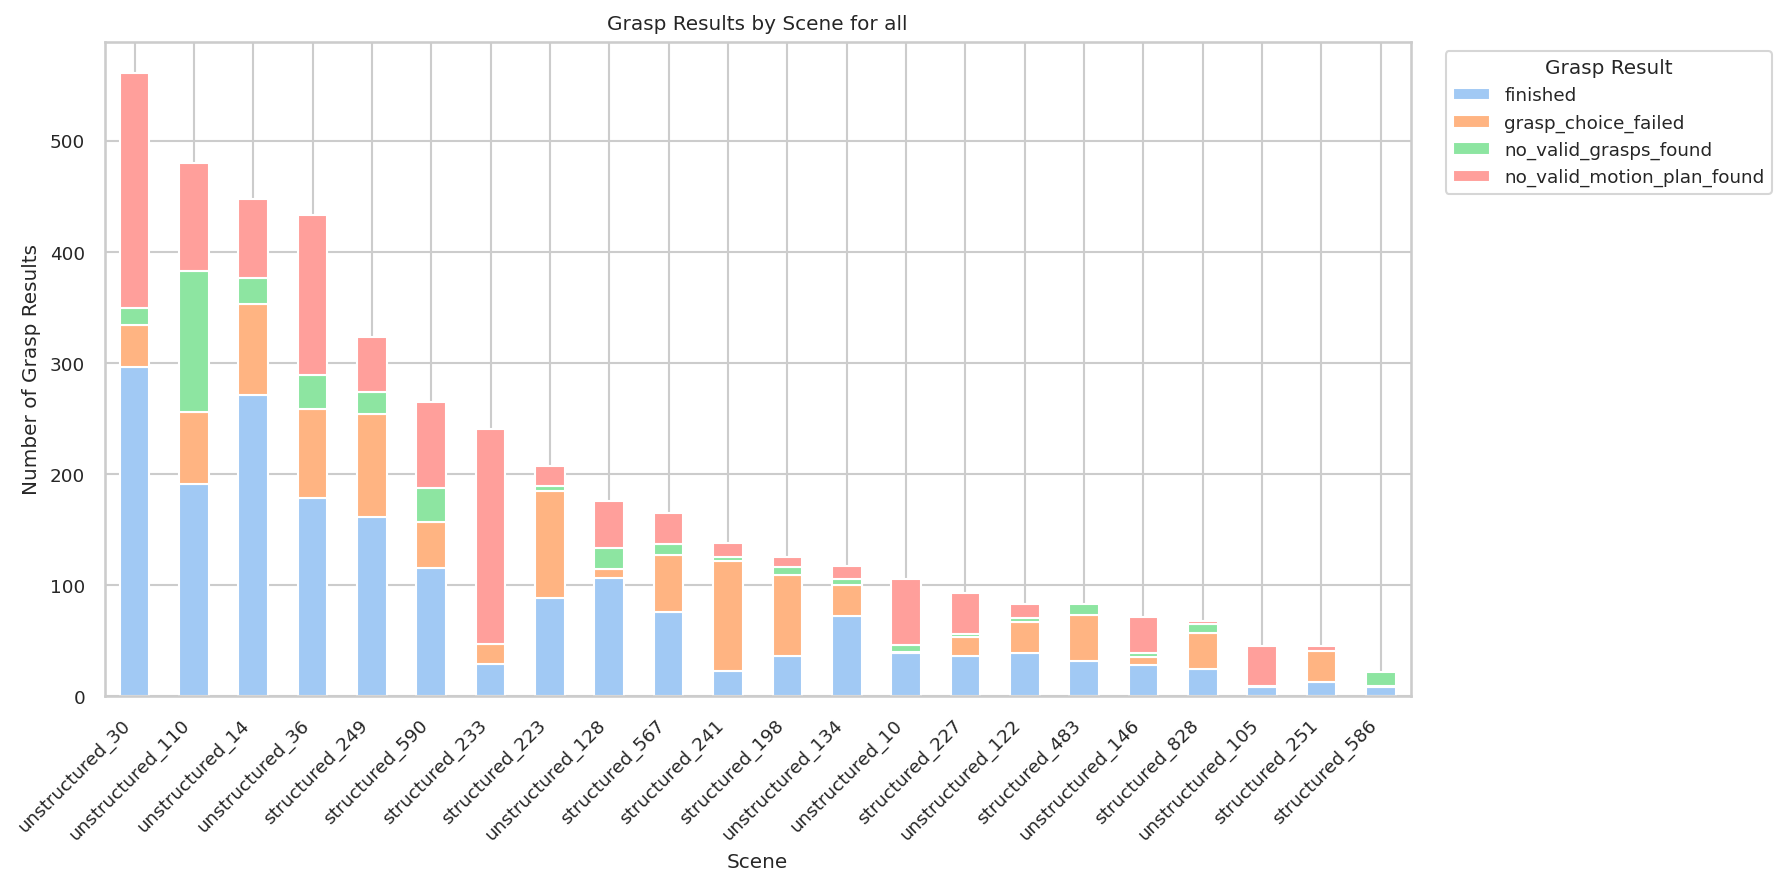

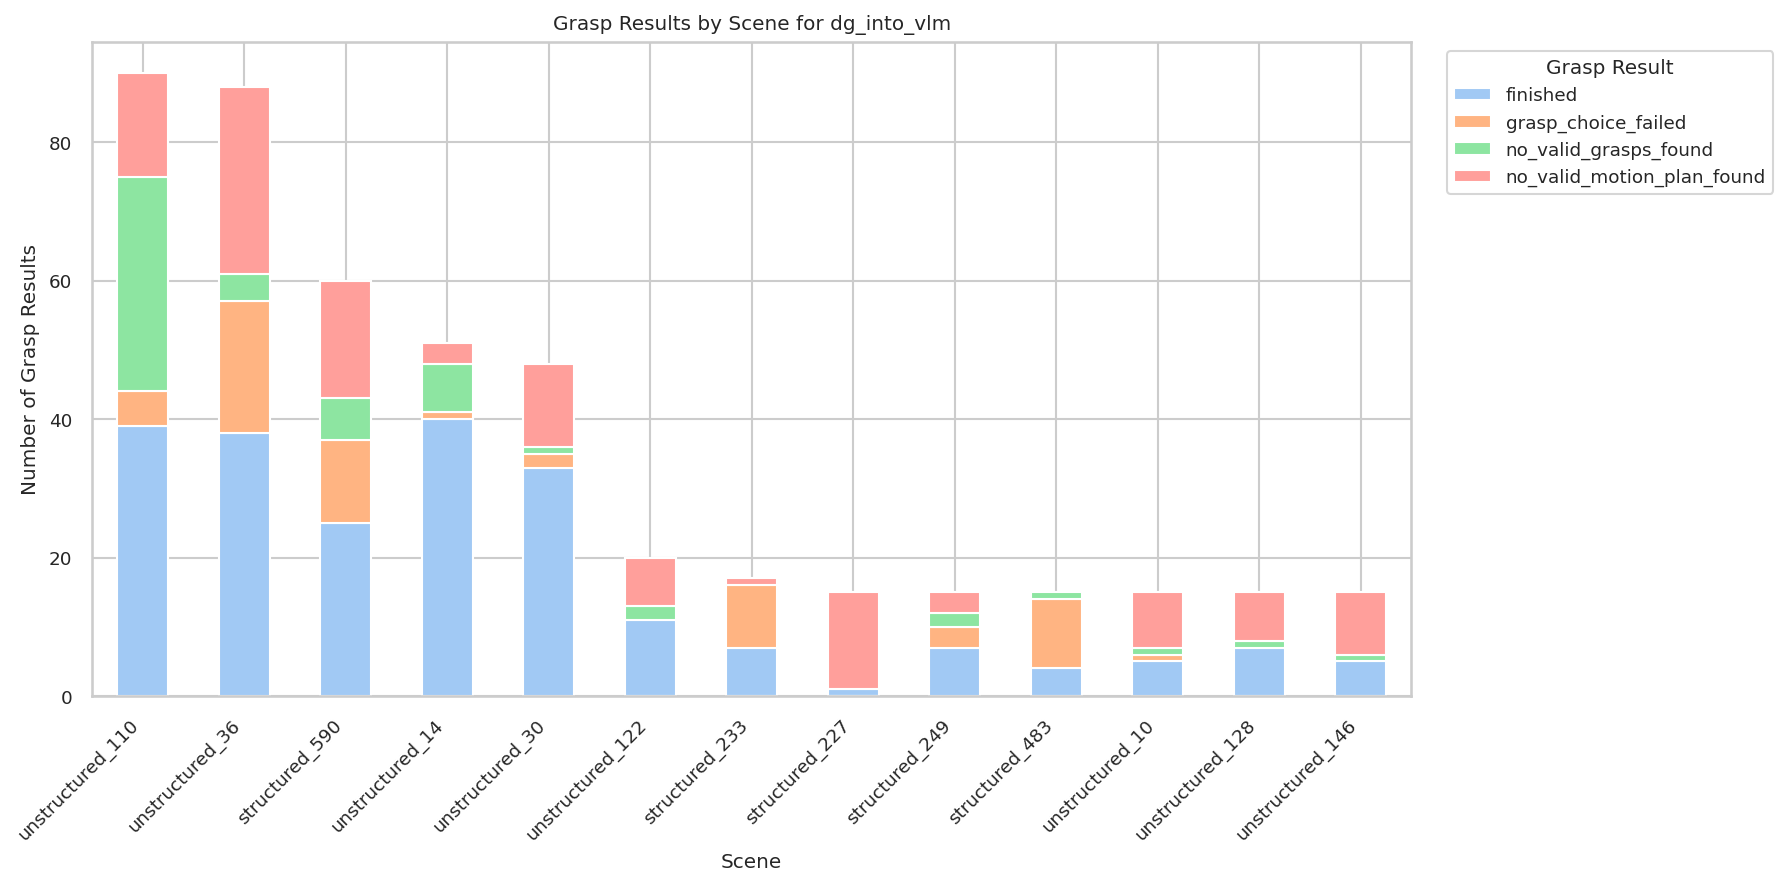

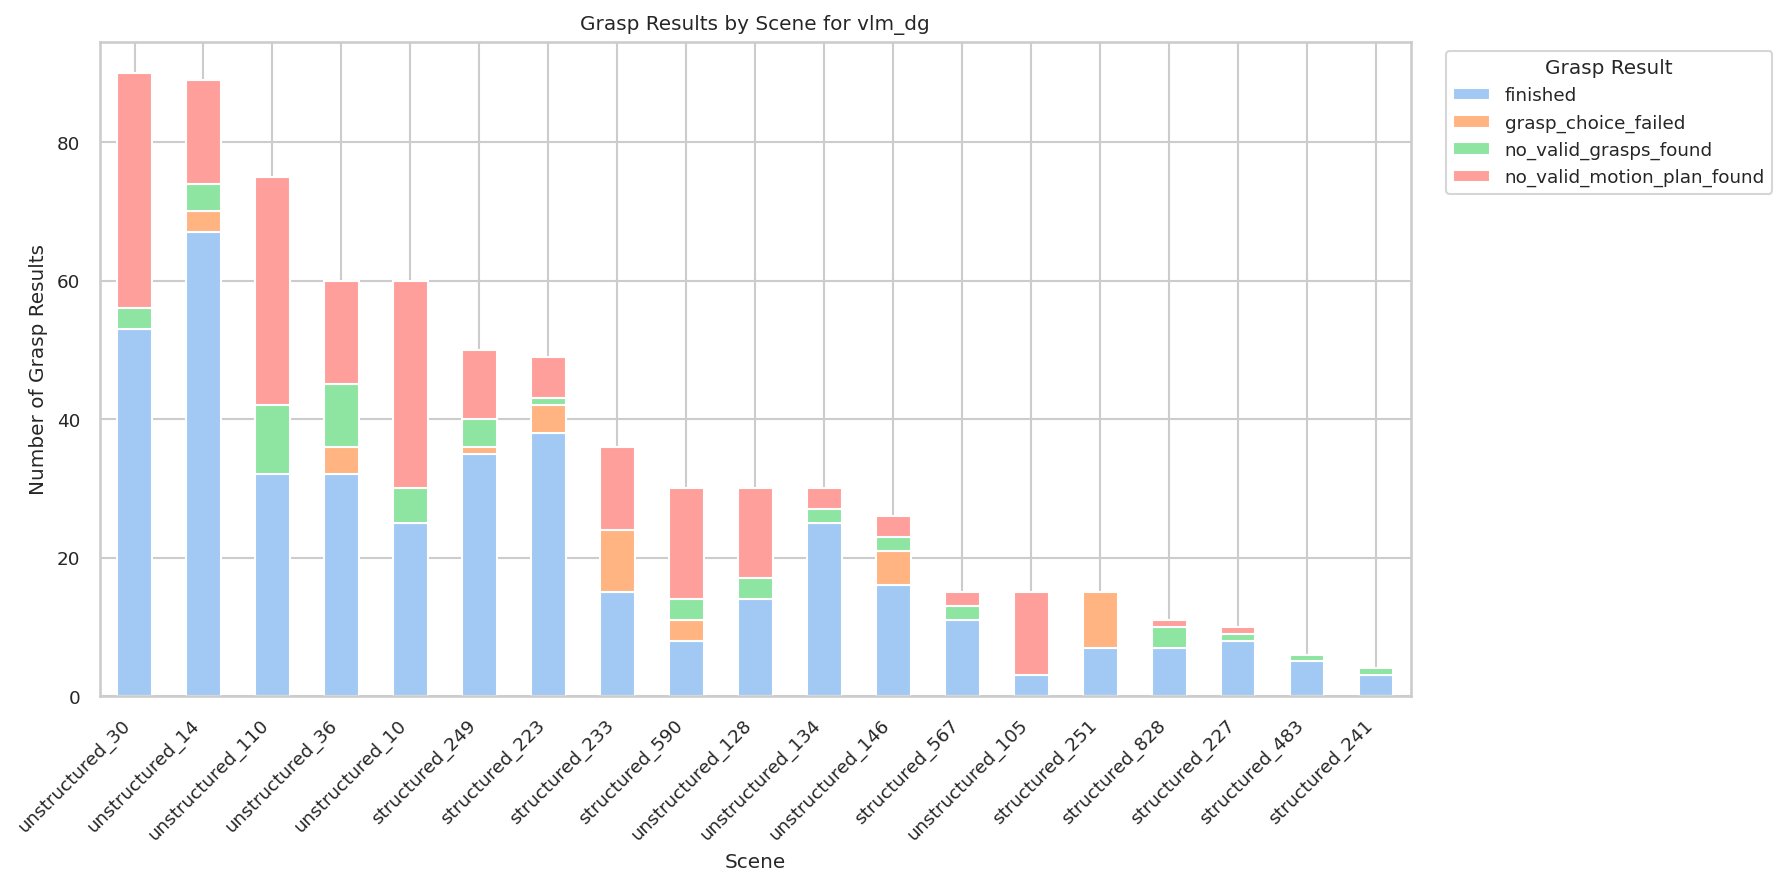

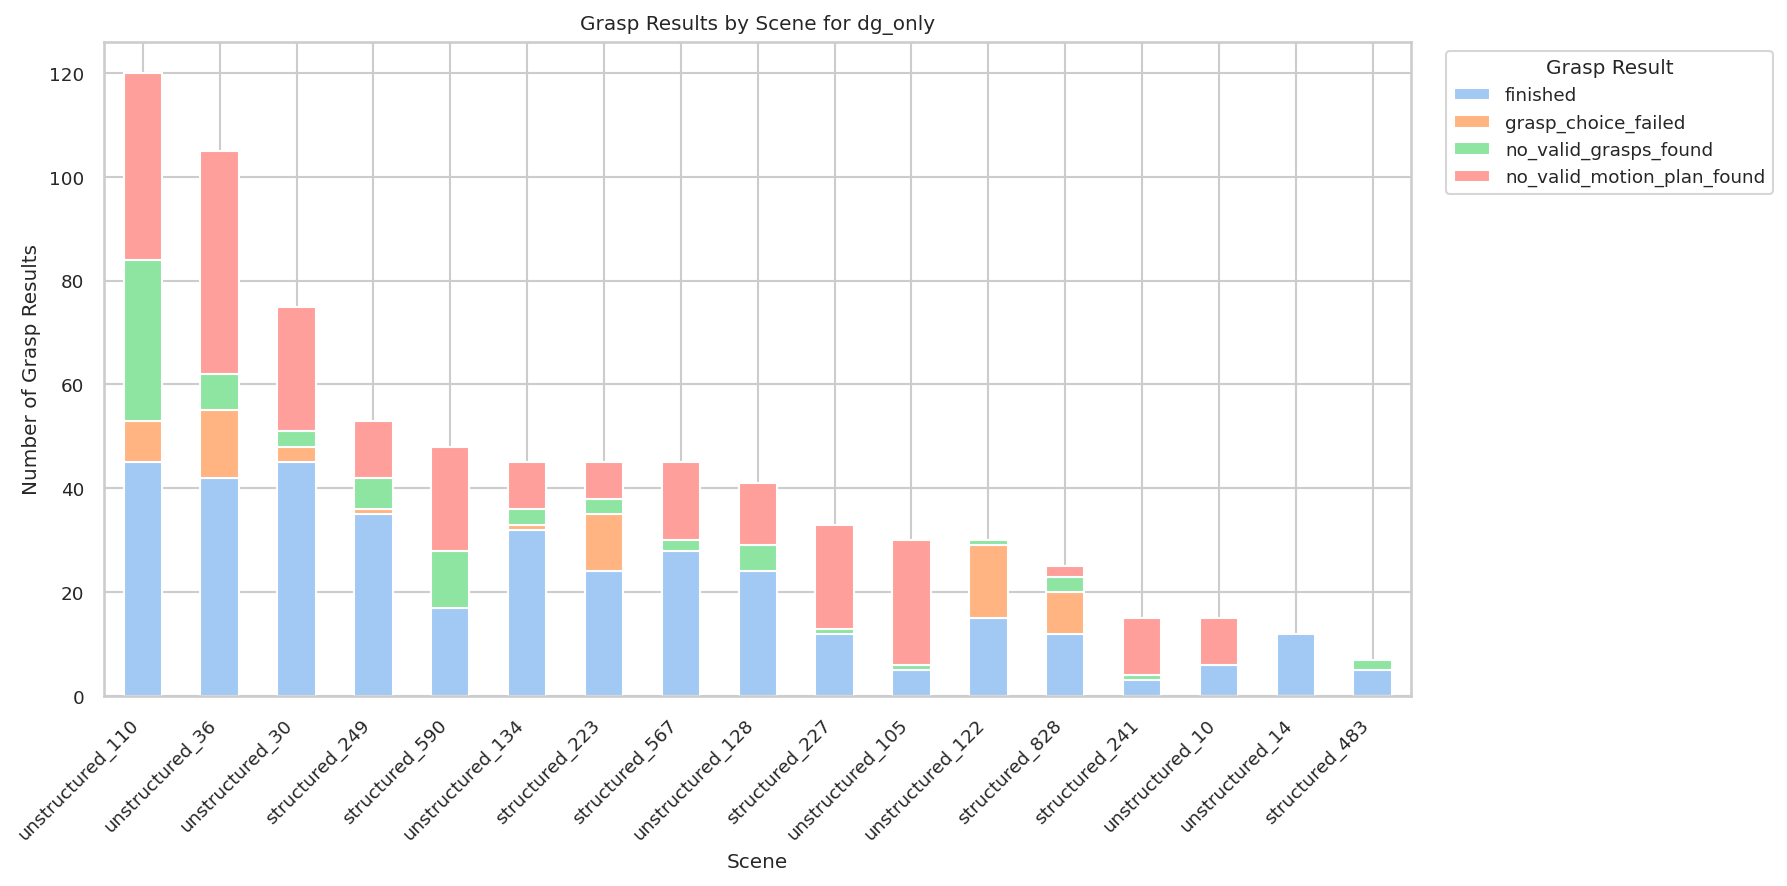

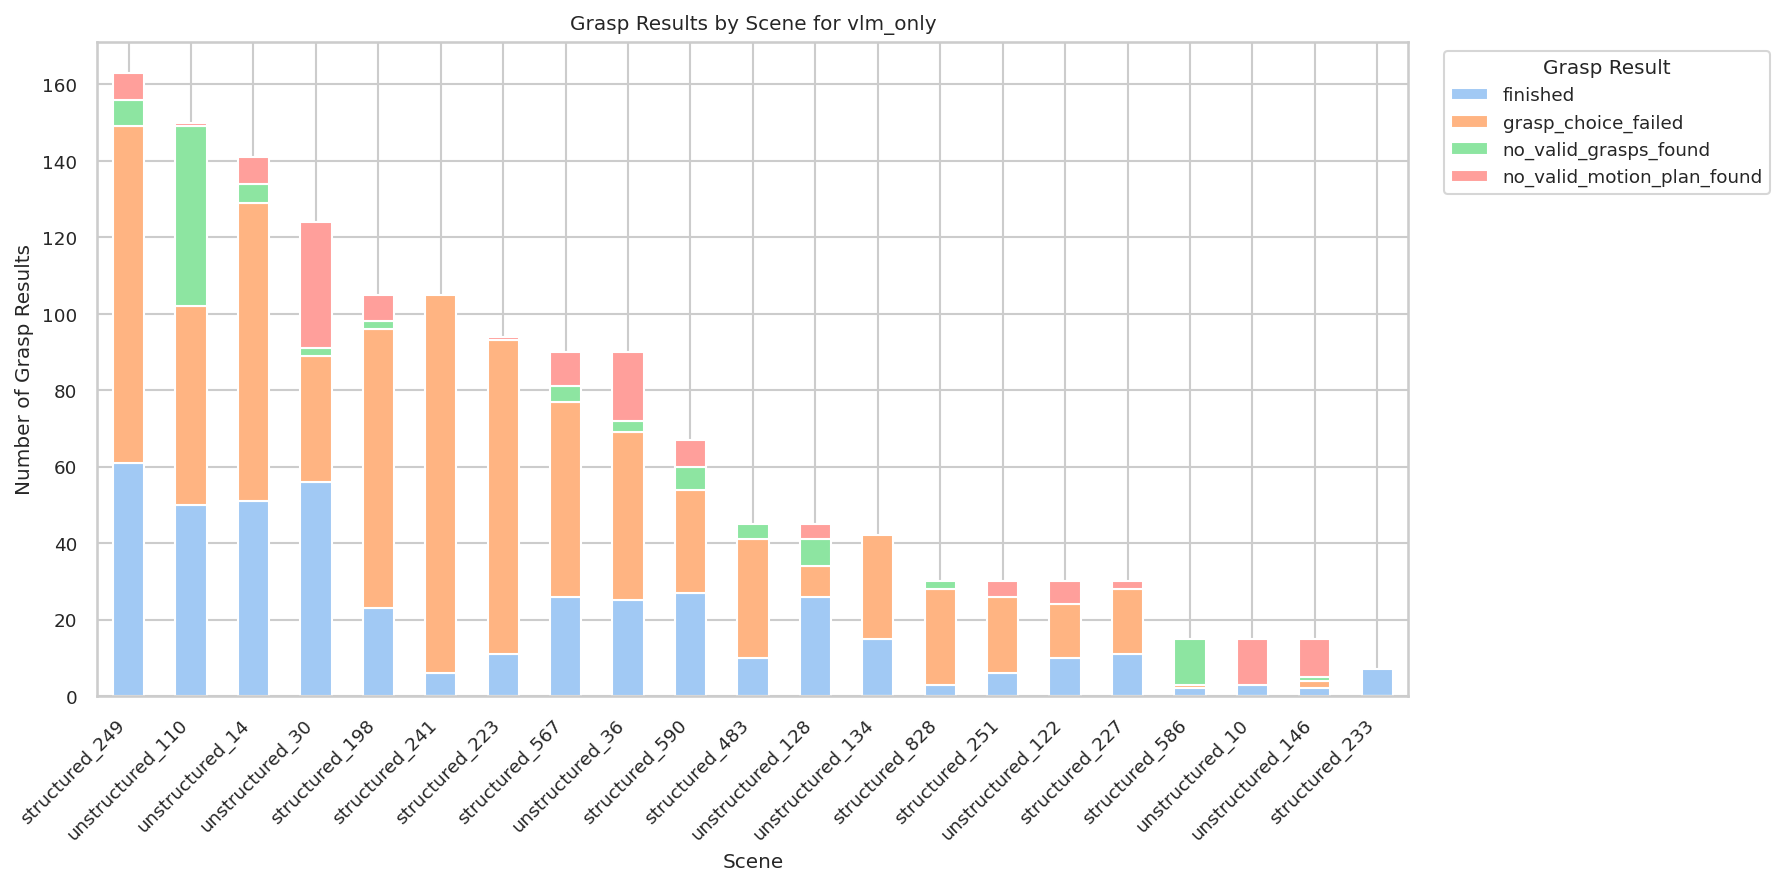

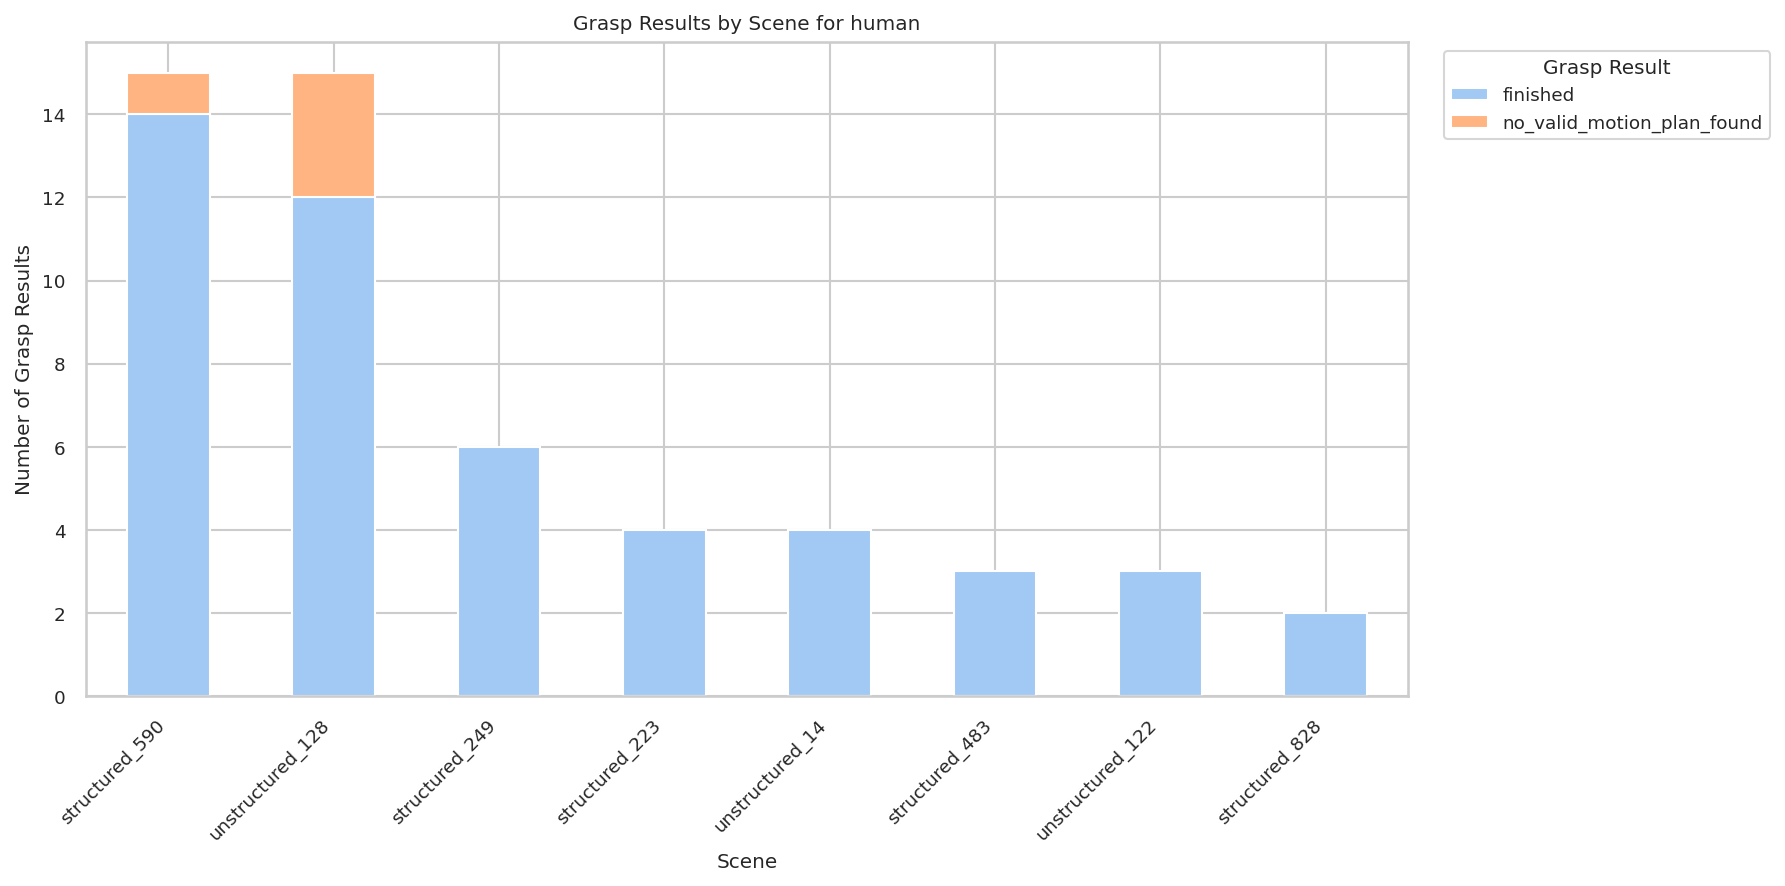

In [49]:
def plot_grasp_result_failure_breakdown(df: pd.DataFrame, method: str = "dg_into_vlm", group_by_target: bool = False):
    if method != "all":
        df = df.loc[
            df["Method"] == method,
        ]

    # Filter for failed experiments only
    failed_df = df.loc[df["Experiment Result"] != "retrieved"].copy()
    if failed_df.empty:
        warn("No failed experiments found (all Experiment Result values are 'retrieved').")
        return

    # Extract all grasp results (including finished) and expand them
    grasp_results = []
    for idx, row in failed_df.iterrows():
        scene = row["Scene"]
        target_object = row["Target Object"]
        grasp_result_str = row["Grasp Result"]
        
        # Skip if no grasp results
        if pd.isna(grasp_result_str) or grasp_result_str == "":
            continue
        
        # Split grasp results and add each one
        for grasp_result in grasp_result_str.split(","):
            grasp_result = grasp_result.strip()
            if grasp_result:
                grasp_results.append({"Scene": scene, "Target Object": target_object, "Grasp Result": grasp_result})
    
    if not grasp_results:
        warn("No grasp results found in failed experiments.")
        return
    
    grasp_df = pd.DataFrame(grasp_results)
    
    # Group by Scene (and optionally Target Object) and Grasp Result
    if group_by_target:
        groupby_cols = ["Scene", "Target Object", "Grasp Result"]
        xlabel = "Scene, Target Object"
    else:
        groupby_cols = ["Scene", "Grasp Result"]
        xlabel = "Scene"
    
    grasp_counts = (
        grasp_df.groupby(groupby_cols)
        .size()
        .unstack(fill_value=0)
    )
    grasp_counts = grasp_counts.loc[grasp_counts.sum(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    grasp_counts.plot(kind="bar", stacked=True, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of Grasp Results")
    ax.set_title(f"Grasp Results by Scene for {method}")
    plt.xticks(rotation=45, ha="right")
    ax.legend(title="Grasp Result", bbox_to_anchor=(1.02, 1), loc="upper left")
    
    plt.tight_layout()
    output_path = f"{PLOTS_PATH}/grasp_result_{to_snake_case(method)}.png"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_grasp_result_failure_breakdown(ex_df, "all")
plot_grasp_result_failure_breakdown(ex_df, "dg_into_vlm")
plot_grasp_result_failure_breakdown(ex_df, "vlm_dg")
plot_grasp_result_failure_breakdown(ex_df, "dg_only")
plot_grasp_result_failure_breakdown(ex_df, "vlm_only")
plot_grasp_result_failure_breakdown(ex_df, "human")

In [36]:
def save_csv(df: pd.DataFrame):
    # Export failed experiments to CSV
    failed_experiments = df.loc[
        df["Experiment Result"] != "retrieved",
        ["Method", "Scene", "Experiment Result", "Experiment Path"]
    ].copy()

    # Sort by Method, then Scene, then Experiment Result
    failed_experiments = failed_experiments.sort_values(
        by=["Method", "Experiment Result", "Scene"]
    )

    # Save to CSV
    output_csv_path = f"{PLOTS_PATH}/failed_experiments.csv"
    failed_experiments.to_csv(output_csv_path, index=False)
    print(f"Saved {len(failed_experiments)} failed experiments to {output_csv_path}")

    # Display first few rows
    display(failed_experiments.head(20))

save_csv(ex_df)

Saved 334 failed experiments to ./plots/failed_experiments.csv


,Method,Scene,Experiment Result,Experiment Path
1582,dg_into_vlm,structured_233,dropped,trial_2026-02-28_02-16-30__all__all_auto/struc...
954,dg_into_vlm,unstructured_122,dropped,trial_2026-02-28_02-16-26__all__all_auto/unstr...
1418,dg_into_vlm,unstructured_14,dropped,trial_2026-02-28_02-16-33__all__all_auto/unstr...
197,dg_into_vlm,unstructured_30,dropped,trial_2026-02-28_02-16-28__all__all_auto/unstr...
397,dg_into_vlm,unstructured_30,dropped,trial_2026-02-28_02-16-25__all__all_auto/unstr...
440,dg_into_vlm,unstructured_30,dropped,trial_2026-02-28_02-16-25__all__all_auto/unstr...
797,dg_into_vlm,unstructured_30,dropped,trial_2026-02-28_02-16-34__all__all_auto/unstr...
1474,dg_into_vlm,unstructured_30,dropped,trial_2026-02-28_02-16-33__all__all_auto/unstr...
1496,dg_into_vlm,unstructured_36,dropped,trial_2026-02-28_02-16-30__all__all_auto/unstr...
1285,dg_into_vlm,structured_227,timeout,trial_2026-02-28_02-16-33__all__all_auto/struc...


In [4]:
# ^^^^^^^^^^ ADD NEW CODE BLOCKS ABOVE ^^^^^^^^^^ #

# Check to see if there are any errors.
check_results()

Data Analysis Results:
